En python construir un grid 15x15 con 5 obstaculos, un inicio y un final. Usando politica de direccion y metodos de valores para trazar el mejor camino entre inicio y fin. Mostrar agente con RL e iteraciones

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [2]:
N = 15
inicio = (0, 0)
meta = (14, 14)
obstaculos = {(3, 4), (5, 9), (8, 6), (10, 12), (12, 3)}

acciones = [(-1, 0), (1, 0), (0, -1), (0, 1)]
nombres_acciones = ["↑", "↓", "←", "→"]

def valido(pos):
    return (
        0 <= pos[0] < N and
        0 <= pos[1] < N and
        pos not in obstaculos
    )

def mover(pos, accion):
    nueva_pos = (pos[0] + accion[0], pos[1] + accion[1])
    return nueva_pos if valido(nueva_pos) else pos

In [3]:
# 1. Iteración de valores

V = np.zeros((N, N))
gamma = 0.95
historial_V = []

for iteracion in range(200):
    nuevo_V = V.copy()

    for fila in range(N):
        for columna in range(N):
            estado = (fila, columna)

            if estado in obstaculos:
                continue
            if estado == meta:
                nuevo_V[estado] = 100
                continue

            valores = []
            for accion in acciones:
                siguiente = mover(estado, accion)
                recompensa = 100 if siguiente == meta else -1
                valores.append(recompensa + gamma * V[siguiente])

            nuevo_V[estado] = max(valores)

    historial_V.append(nuevo_V.copy())

    if np.max(np.abs(nuevo_V - V)) < 1e-4:
        break

    V = nuevo_V

# Política óptima derivada de los valores
politica = {}

for fila in range(N):
    for columna in range(N):
        estado = (fila, columna)

        if not valido(estado) or estado == meta:
            continue

        valores = []
        for accion in acciones:
            siguiente = mover(estado, accion)
            recompensa = 100 if siguiente == meta else -1
            valores.append(recompensa + gamma * V[siguiente])

        politica[estado] = np.argmax(valores)

# Camino según la política de valores
camino_valores = [inicio]
estado = inicio

for _ in range(N * N):
    if estado == meta:
        break

    accion = acciones[politica[estado]]
    siguiente = mover(estado, accion)

    if siguiente == estado:
        break

    camino_valores.append(siguiente)
    estado = siguiente


In [4]:
# 2. Aprendizaje por refuerzo Q-Learning

Q = np.zeros((N, N, len(acciones)))
episodios = 3000
alpha = 0.1
gamma = 0.95
epsilon = 1.0
recompensas = []

rng = np.random.default_rng(7)

for episodio in range(episodios):
    estado = inicio
    recompensa_total = 0

    for _ in range(500):
        if rng.random() < epsilon:
            accion_id = rng.integers(len(acciones))
        else:
            accion_id = np.argmax(Q[estado])

        siguiente = mover(estado, acciones[accion_id])

        if siguiente == meta:
            recompensa = 100
        elif siguiente == estado:
            recompensa = -5
        else:
            recompensa = -1

        mejor_siguiente = np.max(Q[siguiente])
        Q[estado + (accion_id,)] += alpha * (
            recompensa + gamma * mejor_siguiente - Q[estado + (accion_id,)]
        )

        estado = siguiente
        recompensa_total += recompensa

        if estado == meta:
            break

    epsilon = max(0.05, epsilon * 0.995)
    recompensas.append(recompensa_total)

# Camino aprendido por Q-Learning
camino_rl = [inicio]
estado = inicio

for _ in range(N * N):
    if estado == meta:
        break

    accion_id = np.argmax(Q[estado])
    siguiente = mover(estado, acciones[accion_id])

    if siguiente == estado or siguiente in camino_rl:
        break

    camino_rl.append(siguiente)
    estado = siguiente

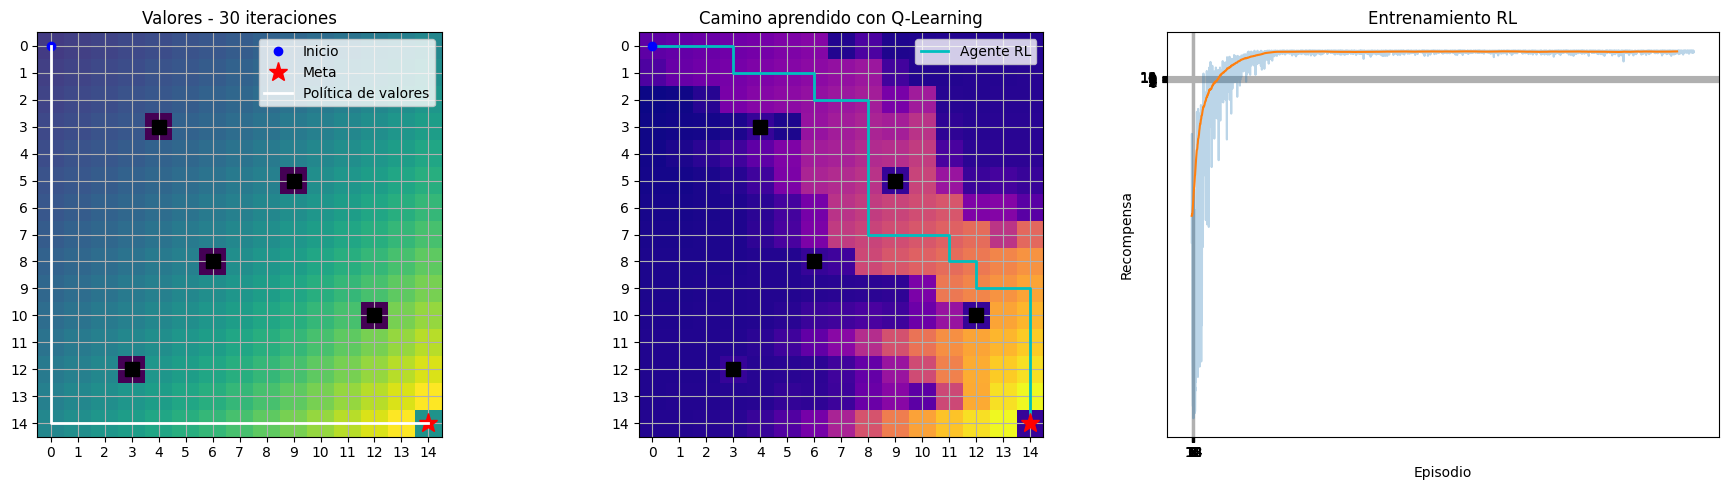

In [5]:
# Visualización de resultados

fig, ejes = plt.subplots(1, 3, figsize=(18, 5))

# Valores finales
ejes[0].imshow(V, cmap="viridis")
ejes[0].set_title(f"Valores - {len(historial_V)} iteraciones")
ejes[0].plot(inicio[1], inicio[0], "bo", label="Inicio")
ejes[0].plot(meta[1], meta[0], "r*", markersize=14, label="Meta")

for obstaculo in obstaculos:
    ejes[0].plot(obstaculo[1], obstaculo[0], "ks", markersize=10)

ejes[0].plot(
    [p[1] for p in camino_valores],
    [p[0] for p in camino_valores],
    "w-", linewidth=2,
    label="Política de valores"
)
ejes[0].legend()

# Camino Q-Learning
ejes[1].imshow(np.max(Q, axis=2), cmap="plasma")
ejes[1].set_title("Camino aprendido con Q-Learning")
ejes[1].plot(
    [p[1] for p in camino_rl],
    [p[0] for p in camino_rl],
    "c-", linewidth=2,
    label="Agente RL"
)
ejes[1].plot(inicio[1], inicio[0], "bo")
ejes[1].plot(meta[1], meta[0], "r*", markersize=14)

for obstaculo in obstaculos:
    ejes[1].plot(obstaculo[1], obstaculo[0], "ks", markersize=10)

ejes[1].legend()

# Recompensas durante el entrenamiento
ejes[2].plot(recompensas, alpha=0.3)
ejes[2].plot(
    np.convolve(recompensas, np.ones(100) / 100, mode="valid")
)
ejes[2].set_title("Entrenamiento RL")
ejes[2].set_xlabel("Episodio")
ejes[2].set_ylabel("Recompensa")

for eje in ejes:
    eje.set_xticks(range(N))
    eje.set_yticks(range(N))
    eje.grid(True)

plt.tight_layout()
plt.show()

In [6]:
# Animación del agente RL
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-0.5, N - 0.5)
ax.set_ylim(N - 0.5, -0.5)
ax.set_xticks(range(N))
ax.set_yticks(range(N))
ax.grid(True)

for obstaculo in obstaculos:
    ax.plot(obstaculo[1], obstaculo[0], "ks", markersize=15)

ax.plot(inicio[1], inicio[0], "bo", markersize=12, label="Inicio")
ax.plot(meta[1], meta[0], "r*", markersize=16, label="Meta")
agente, = ax.plot([], [], "go", markersize=12, label="Agente RL")
ax.legend()

def actualizar(frame):
    posicion = camino_rl[min(frame, len(camino_rl) - 1)]
    agente.set_data([posicion[1]], [posicion[0]])
    ax.set_title(f"Agente RL - iteración {frame + 1}/{len(camino_rl)}")
    return agente,

animacion = FuncAnimation(
    fig,
    actualizar,
    frames=len(camino_rl),
    interval=350,
    repeat=False
)

plt.close(fig)
HTML(animacion.to_jshtml())

### Comparación
En que casos funciona mejor el metodo de politica
- **Iteración de política:** puede converger en menos ciclos, pero cada ciclo requiere evaluar una política completa.

En que casos funciona mejor el metodo de valores
- **Iteración de valores:** cada ciclo es más simple y suele ser conveniente en grids grandes o problemas con muchas políticas posibles.

Implementar Q-learning para el grid 15x15 empleado en el ejercicio antreior, comparar resultados con metodos previos

Comparación de métodos
-----------------------------------
Iteración de valores:
  Pasos: 28
  Llegó a la meta: True
  Camino válido: True

Q-Learning:
  Pasos: 28
  Llegó a la meta: True
  Camino válido: True
  Recompensa media últimos 100 episodios: 71.41


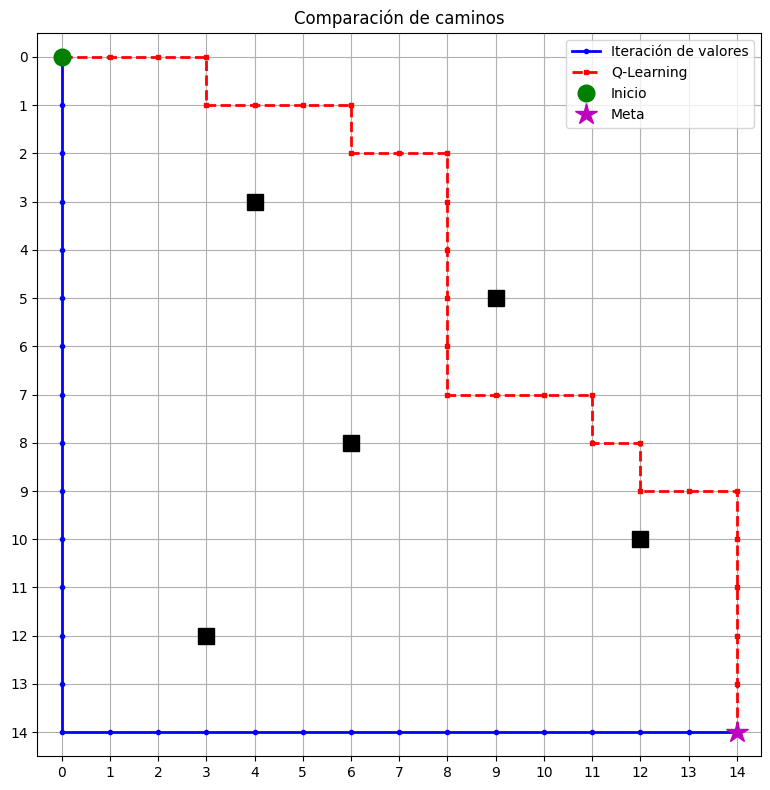

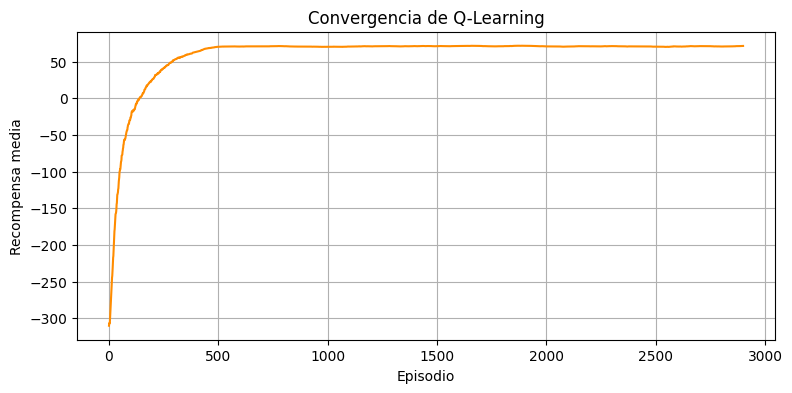

In [8]:
# Comparación entre iteración de valores y Q-Learning

def evaluar_camino(camino):
    pasos = len(camino) - 1
    llego_meta = camino[-1] == meta
    valido_camino = all(valido(pos) for pos in camino)
    return pasos, llego_meta, valido_camino

pasos_valores, exito_valores, valido_valores = evaluar_camino(camino_valores)
pasos_rl, exito_rl, valido_rl = evaluar_camino(camino_rl)

recompensa_media_final = np.mean(recompensas[-100:])
precision_ruta_rl = 100 * exito_rl

print("Comparación de métodos")
print("-" * 35)
print(f"Iteración de valores:")
print(f"  Pasos: {pasos_valores}")
print(f"  Llegó a la meta: {exito_valores}")
print(f"  Camino válido: {valido_valores}")

print("\nQ-Learning:")
print(f"  Pasos: {pasos_rl}")
print(f"  Llegó a la meta: {exito_rl}")
print(f"  Camino válido: {valido_rl}")
print(f"  Recompensa media últimos 100 episodios: "
      f"{recompensa_media_final:.2f}")

# Visualización comparativa de los caminos
fig_comparacion, ax_comparacion = plt.subplots(figsize=(8, 8))

ax_comparacion.imshow(
    np.zeros((N, N)),
    cmap="Greys",
    vmin=0,
    vmax=1
)

for obstaculo in obstaculos:
    ax_comparacion.plot(
        obstaculo[1], obstaculo[0],
        "ks", markersize=12
    )

ax_comparacion.plot(
    [p[1] for p in camino_valores],
    [p[0] for p in camino_valores],
    "b-o", linewidth=2, markersize=3,
    label="Iteración de valores"
)

ax_comparacion.plot(
    [p[1] for p in camino_rl],
    [p[0] for p in camino_rl],
    "r--s", linewidth=2, markersize=3,
    label="Q-Learning"
)

ax_comparacion.plot(
    inicio[1], inicio[0],
    "go", markersize=12, label="Inicio"
)
ax_comparacion.plot(
    meta[1], meta[0],
    "m*", markersize=16, label="Meta"
)

ax_comparacion.set_title("Comparación de caminos")
ax_comparacion.set_xticks(range(N))
ax_comparacion.set_yticks(range(N))
ax_comparacion.grid(True)
ax_comparacion.legend()
plt.tight_layout()
plt.show()

# Evolución del aprendizaje
plt.figure(figsize=(9, 4))
ventana_comparacion = 100
media_recompensas = np.convolve(
    recompensas,
    np.ones(ventana_comparacion) / ventana_comparacion,
    mode="valid"
)

plt.plot(media_recompensas, color="darkorange")
plt.title("Convergencia de Q-Learning")
plt.xlabel("Episodio")
plt.ylabel("Recompensa media")
plt.grid(True)
plt.show()

### Casos de Aplicacion RL


1. Robótica y Vehículos Autónomos

- Conducción autónoma: Coches autónomos emplean algoritmos para aprender a girar, acelerar y frenar con base en datos de cámaras y sensores.

- Control de robots: Robots manipuladores aprenden a ensamblar piezas complejas o ajustar su fuerza de agarre ante imprevistos.

2. Gestión de Energía y Eficiencia

- Refrigeración de centros de datos: Sistemas de Google usan modelos de refuerzo para enfriar servidores de forma autónoma, reduciendo el consumo eléctrico masivo.

- Redes inteligente: Distribución dinámica de energía eléctrica según la demanda en tiempo real.

3. Videojuegos e Inteligencia Artificial General

- Juegos de estrategia: Hitos históricos como AlphaGo o modelos entrenados en StarCraft II y ajedrez que superan a humanos.

- Alineación de Modelos de Lenguaje (RLHF): Ajuste de grandes modelos de texto mediante retroalimentación humana para mejorar la utilidad y seguridad de sus respuestas.

4. Finanzas y Comercio

- Trading algorítmico: Ejecución automática de compra y venta de activos financieros para maximizar el retorno a largo plazo.

- Gestión de carteras: Optimización de la asignación de recursos e inventarios bajo condiciones de mercado inciertas.

Implementar un algoritmo que use RL para autoreconocimiento de un numeros usando MNIST database

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Precisión del agente RL: 93.52%


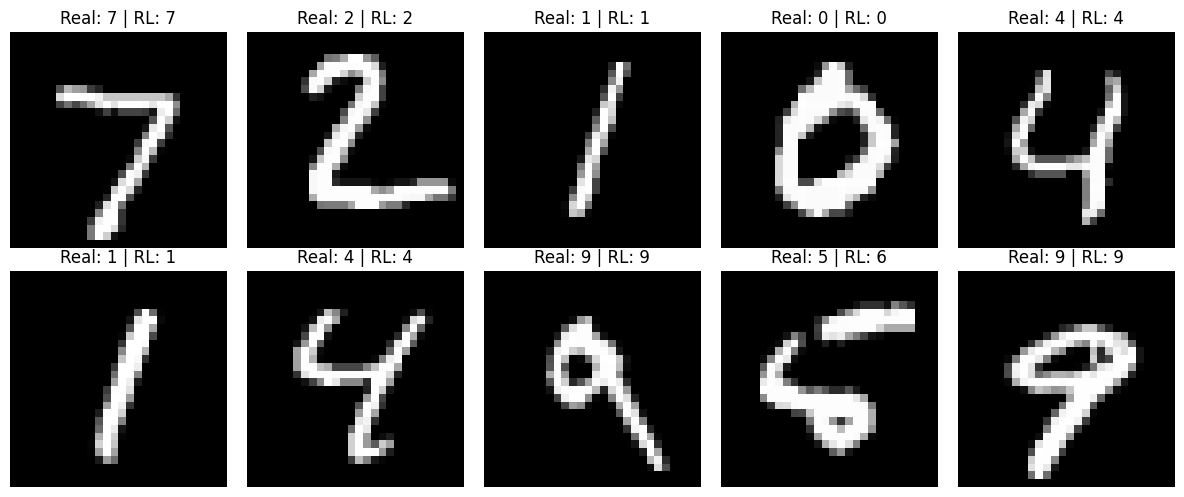

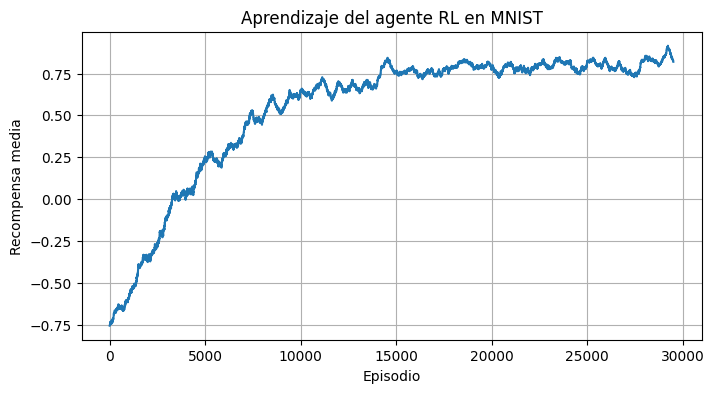

In [7]:
import tensorflow as tf

# Clasificación de dígitos MNIST mediante RL
# Se utiliza un agente Q con una red neuronal como aproximador de valores.


(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalización y aplanado de las imágenes
mnist_x_train = x_train.astype("float32").reshape(-1, 784) / 255.0
mnist_x_test = x_test.astype("float32").reshape(-1, 784) / 255.0

# Subconjunto para acelerar el entrenamiento
muestras_entrenamiento = 20000
mnist_x_train = mnist_x_train[:muestras_entrenamiento]
mnist_y_train = y_train[:muestras_entrenamiento]

modelo_rl = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation=None)
])

optimizador_rl = tf.keras.optimizers.Adam(learning_rate=0.001)
rng_mnist = np.random.default_rng(10)

episodios_mnist = 30000
epsilon_mnist = 1.0
epsilon_minimo = 0.05
decaimiento_epsilon = 0.9998
recompensas_mnist = []

for episodio_mnist in range(episodios_mnist):
    indice = rng_mnist.integers(len(mnist_x_train))
    estado_mnist = mnist_x_train[indice:indice + 1]
    etiqueta_mnist = int(mnist_y_train[indice])

    valores_q = modelo_rl(estado_mnist, training=False).numpy()[0]

    if rng_mnist.random() < epsilon_mnist:
        accion_mnist = int(rng_mnist.integers(10))
    else:
        accion_mnist = int(np.argmax(valores_q))

    recompensa_mnist = 1.0 if accion_mnist == etiqueta_mnist else -1.0

    # Actualización Q usando la recompensa inmediata
    objetivo_q = valores_q.copy()
    objetivo_q[accion_mnist] += 0.1 * (
        recompensa_mnist - objetivo_q[accion_mnist]
    )

    with tf.GradientTape() as cinta:
        prediccion_q = modelo_rl(estado_mnist, training=True)
        perdida_q = tf.reduce_mean(
            tf.square(prediccion_q - objetivo_q.reshape(1, 10))
        )

    gradientes = cinta.gradient(perdida_q, modelo_rl.trainable_variables)
    optimizador_rl.apply_gradients(
        zip(gradientes, modelo_rl.trainable_variables)
    )

    epsilon_mnist = max(
        epsilon_minimo,
        epsilon_mnist * decaimiento_epsilon
    )
    recompensas_mnist.append(recompensa_mnist)

# Evaluación del agente
q_test = modelo_rl.predict(mnist_x_test, verbose=0)
predicciones_mnist = np.argmax(q_test, axis=1)
precision_mnist = np.mean(predicciones_mnist == y_test)

print(f"Precisión del agente RL: {precision_mnist:.2%}")

# Mostrar ejemplos reconocidos
fig_mnist, ejes_mnist = plt.subplots(2, 5, figsize=(12, 5))

for eje_mnist, indice_mnist in zip(ejes_mnist.ravel(), range(10)):
    eje_mnist.imshow(x_test[indice_mnist], cmap="gray")
    eje_mnist.set_title(
        f"Real: {y_test[indice_mnist]} | "
        f"RL: {predicciones_mnist[indice_mnist]}"
    )
    eje_mnist.axis("off")

plt.tight_layout()
plt.show()

# Evolución de las recompensas
plt.figure(figsize=(8, 4))
plt.plot(
    np.convolve(
        recompensas_mnist,
        np.ones(500) / 500,
        mode="valid"
    )
)
plt.title("Aprendizaje del agente RL en MNIST")
plt.xlabel("Episodio")
plt.ylabel("Recompensa media")
plt.grid(True)
plt.show()